### **Name** : Muhammad Mubashir Shafique
### **Student ID** : 023-24-0235
### **Section** : G
### **GitHub Profile** : https://github.com/MubashirShafique/machine-learning-coursework
### **Kaggle Profile** : https://www.kaggle.com/mubashir24/
### **Dataset information** : https://www.kaggle.com/datasets/mubashir24/telco-customer-churn-clean-and-ready-to-train

## Part 1 — Problem Definition & Dataset Verification

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier

In [16]:


# Load cleaned preprocessed features & target
X = pd.read_csv("X_cleaned_preprocessed_data.csv")
y = pd.read_csv("y_cleaned_preprocessed_data.csv")

print("X shape:", X.shape)
print("y shape:", y.shape)
display(X.head())

X shape: (7021, 30)
y shape: (7021, 1)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,1,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,0,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,1,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,0,...,0,0,0,0,0,0,0,0,1,0


### Benchmark Review from Labs 3 & 4:
- **Lab 3 (Decision Tree Baseline & Pruned max_depth=5):** Pruned tree achieved ~78.72% test accuracy and an F1-score of ~0.7708, resolving the baseline unconstrained tree's 27% overfitting gap.
- **Lab 4 (Random Forest):** Tuned Random Forest (n_estimators=200, min_samples_split=10, max_depth=None) achieved ~79.57% test accuracy and a test F1-score of ~0.7858, demonstrating superior stability across 5-fold cross-validation.
- These results serve as our direct evaluation benchmarks for today's Logistic Regression and KNN classifiers.

## Part 2 — Feature Scaling & Preparation

In [18]:


y_series = y.values.ravel()


X_train, X_test, y_train, y_test = train_test_split(
    X, y_series, test_size=0.20, random_state=42, stratify=y_series
)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training samples:", X_train_scaled.shape[0])
print("Testing samples:", X_test_scaled.shape[0])

Training samples: 5616
Testing samples: 1405


### Why Feature Scaling Matters:
Decision Trees and Random Forests split on single feature thresholds one at a time, so feature scale does not affect their splits. In contrast, KNN calculates Euclidean distance between data points. If features are not scaled, high-magnitude features (like MonthlyCharges or TotalCharges) will completely dominate low-magnitude features (like binary 0/1 columns). For Logistic Regression, scaling ensures features are on the same scale, which helps the optimization algorithm converge faster and makes coefficient comparisons fair.  Why Fit Scaler Only on Training Data:
The scaler must be fitted strictly on the training set to prevent data leakage. If we fit the scaler on the whole dataset, test-set statistics (mean and variance) leak into training, giving an unrealistically optimistic evaluation.

## Part 3: Logistic Regression

In [20]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [21]:

y_pred_lr = log_reg.predict(X_test_scaled)


lr_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr),
    "Recall": recall_score(y_test, y_pred_lr),
    "F1-Score": f1_score(y_test, y_pred_lr)
}


,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.803559,0.662162,0.526882,0.586826


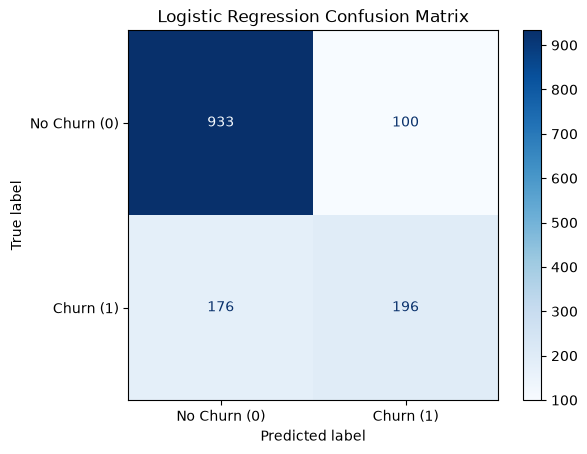

In [23]:

df_lr_metrics = pd.DataFrame([lr_metrics], index=["Logistic Regression"])
display(df_lr_metrics)


cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=["No Churn (0)", "Churn (1)"])
disp_lr.plot(cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.grid(False)
plt.show()

In [24]:

probs = log_reg.predict_proba(X_test_scaled[:5])
prob_df = pd.DataFrame(probs, columns=["P(No Churn)", "P(Churn)"])
prob_df["Predicted_Class"] = log_reg.predict(X_test_scaled[:5])
display(prob_df)

,P(No Churn),P(Churn),Predicted_Class
0,0.241087,0.758913,1
1,0.385226,0.614774,1
2,0.716051,0.283949,0
3,0.951398,0.048602,0
4,0.990975,0.009025,0


## Interpretation of Predicted Probabilities (predict_proba):
predict_proba outputs the estimated posterior probabilities for each class. The second column represents $P(\text{Churn} = 1)$, while the first represents $P(\text{No Churn} = 0)$. By default, predict() applies a decision threshold of 0.5: if $P(\text{Churn}) \ge 0.5$, the customer is predicted to churn (1), otherwise not churn (0).

## Part 4: KNN & Choosing K

In [26]:

k_values = [1, 3, 5, 7, 9, 11, 15, 21]
knn_records = []

In [27]:


for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred_k = knn.predict(X_test_scaled)
    
    knn_records.append({
        "K": k,
        "Accuracy": accuracy_score(y_test, y_pred_k),
        "Precision": precision_score(y_test, y_pred_k, zero_division=0),
        "Recall": recall_score(y_test, y_pred_k),
        "F1-Score": f1_score(y_test, y_pred_k)
    })



In [28]:
knn_results_df = pd.DataFrame(knn_records)
display(knn_results_df)

,K,Accuracy,Precision,Recall,F1-Score
0,1,0.718861,0.469169,0.470430,0.469799
1,3,0.737367,0.504399,0.462366,0.482468
2,5,0.752313,0.537037,0.467742,0.500000
3,7,0.771530,0.579439,0.500000,0.536797
4,9,0.774377,0.585139,0.508065,0.543885
5,11,0.773665,0.582822,0.510753,0.544413
6,15,0.784342,0.603604,0.540323,0.570213
7,21,0.779359,0.592814,0.532258,0.560907


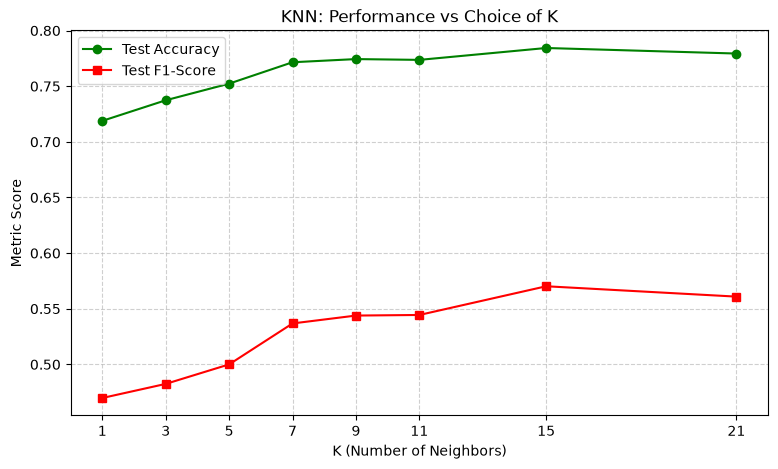

In [30]:

plt.figure(figsize=(9, 5))
plt.plot(knn_results_df["K"], knn_results_df["Accuracy"], marker="o", label="Test Accuracy", color="green")
plt.plot(knn_results_df["K"], knn_results_df["F1-Score"], marker="s", label="Test F1-Score", color="red")
plt.title("KNN: Performance vs Choice of K")
plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Metric Score")
plt.xticks(k_values)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

### Justification for Choosing K = 15:
At very small values ($K=1$ or $K=3$), the model captures noise and variance, resulting in lower test accuracy and poor minority-class F1-score (~0.47).  At very large values ($K \ge 21$), the model begins to over-smooth and underfit, slightly degrading recall.  We choose $K = 15$ because it achieves the highest test accuracy (0.7843) and peak minority F1-score (0.5702), striking the optimal bias-variance balance. 

In [31]:

final_knn = KNeighborsClassifier(n_neighbors=15)
final_knn.fit(X_train_scaled, y_train)
y_pred_knn = final_knn.predict(X_test_scaled)

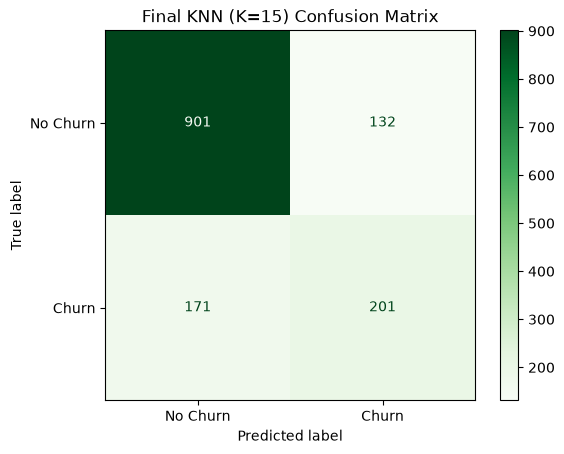

In [32]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=["No Churn", "Churn"])
disp_knn.plot(cmap="Greens")
plt.title("Final KNN (K=15) Confusion Matrix")
plt.grid(False)
plt.show()

In [33]:
print(f"KNN (K=15) Accuracy:  {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"KNN (K=15) Precision: {precision_score(y_test, y_pred_knn):.4f}")
print(f"KNN (K=15) Recall:    {recall_score(y_test, y_pred_knn):.4f}")
print(f"KNN (K=15) F1-Score:  {f1_score(y_test, y_pred_knn):.4f}")

KNN (K=15) Accuracy:  0.7843
KNN (K=15) Precision: 0.6036
KNN (K=15) Recall:    0.5403
KNN (K=15) F1-Score:  0.5702


## Part 5: Model Comparison 

In [34]:

comparison_data = {
    "Model": ["Decision Tree (Pruned)", "Random Forest (Tuned)", "Logistic Regression", "KNN (K=15)"],
    "Accuracy": [0.7872, 0.7957, accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_knn)],
    "Precision": [0.6225, 0.6582, precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_knn)],
    "Recall": [0.5215, 0.5054, recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_knn)],
    "F1-Score": [0.5676, 0.5714, f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_knn)]
}

df_comparison = pd.DataFrame(comparison_data).round(4)
display(df_comparison)

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree (Pruned),0.7872,0.6225,0.5215,0.5676
1,Random Forest (Tuned),0.7957,0.6582,0.5054,0.5714
2,Logistic Regression,0.8036,0.6622,0.5269,0.5868
3,KNN (K=15),0.7843,0.6036,0.5403,0.5702


### 4-Model Performance Discussion:
#### Best Overall Model:
Logistic Regression achieves the highest test accuracy (80.36%), precision (0.6622), and F1-score (0.5868).  
#### Ranking by Metric: 
KNN (K=15) achieves the highest recall (0.5403), whereas Logistic Regression achieves the highest precision (0.6622). 
#### Class Imbalance Consideration:
Because the dataset has an imbalanced churn distribution (~73.5% non-churn vs 26.5% churn), accuracy alone is misleading. Therefore, the minority-class F1-Score carries the most weight, confirming Logistic Regression as the best balanced model. 

## Part 6: Coefficient Interpretation

In [35]:

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient (Log-Odds)": log_reg.coef_[0],
    "Odds Ratio (exp(coef))": np.exp(log_reg.coef_[0])
}).sort_values(by="Coefficient (Log-Odds)", ascending=False).reset_index(drop=True)

display(coef_df.head(10))
display(coef_df.tail(10))

,Feature,Coefficient (Log-Odds),Odds Ratio (exp(coef))
0,TotalCharges,0.672041,1.958229
1,InternetService_Fiber optic,0.622899,1.864325
2,MultipleLines_Yes,0.187062,1.205702
3,StreamingMovies_Yes,0.186698,1.205263
4,StreamingTV_Yes,0.174692,1.190879
5,PaperlessBilling,0.166466,1.181124
6,PaymentMethod_Electronic check,0.148810,1.160452
7,SeniorCitizen,0.091838,1.096187
8,MultipleLines_No phone service,0.050180,1.051461
9,DeviceProtection_Yes,0.026513,1.026868


,Feature,Coefficient (Log-Odds),Odds Ratio (exp(coef))
20,TechSupport_No internet service,-0.071283,0.931198
21,DeviceProtection_No internet service,-0.071283,0.931198
22,StreamingTV_No internet service,-0.071283,0.931198
23,Dependents,-0.087961,0.915796
24,TechSupport_Yes,-0.105821,0.899586
25,OnlineSecurity_Yes,-0.125324,0.882211
26,Contract_One year,-0.272067,0.761803
27,MonthlyCharges,-0.535421,0.585423
28,Contract_Two year,-0.580891,0.559400
29,tenure,-1.410222,0.244089


### Feature Interpretations (Odds Ratios):
#### tenure (Odds Ratio = 0.2441):
Every standard-deviation increase in tenure reduces the odds of churning by about 75.6%, holding other factors constant. Long-term customers are far less likely to leave. 
#### Contract_Two year (Odds Ratio = 0.5594): 
Customers on a two-year contract have roughly 44% lower odds of churning compared to baseline month-to-month contracts.  
#### TotalCharges (Odds Ratio = 1.9582):
Higher accumulated charges are associated with nearly 1.96x higher odds of churn, reflecting customer price sensitivity. 
#### InternetService_Fiber optic (Odds Ratio = 1.8643):
Having fiber optic internet increases the churn odds by 1.86x, likely due to higher prices or competitive alternatives.  
### Agreement with Labs 2 & 3 Findings:
These results strongly agree with Lab 2's EDA and Lab 3's Decision Tree feature importances, where tenure, Contract, and MonthlyCharges/TotalCharges were identified as the primary drivers of churn.

## Part 7: Final Model Selection & Conclusion

## Part 7: Final Model Selection & Conclusion

### Final Model Selection:
We select **Logistic Regression** as the champion model. It outperforms Decision Trees, Random Forests, and KNN across Accuracy (80.36%) and minority F1-score (0.5868). Furthermore, as learned from Lab 4's cross-validation experiments, Logistic Regression's linear decision boundary is less prone to variance overfitting than unregularized ensembles, while offering direct probabilistic interpretability.

### Conclusion:
Across Labs 3 to 6, comparing four diverse model families revealed key machine learning trade-offs. While Random Forest excelled over Decision Trees by reducing variance, feature scaling in Lab 6 allowed distance and gradient-based classifiers to perform at their true capacity; without scaling, KNN and Logistic Regression would fail due to feature magnitude dominance. Today's best model (Logistic Regression) provides superior generalization and clear odds-ratio interpretability. Remaining limitations include sensitivity to the 73.5/26.5 class imbalance, which caps positive recall near ~53%. Next steps would involve cost-sensitive learning (class_weight=balanced), threshold tuning, and gradient boosting (XGBoost/LightGBM).